<a href="https://colab.research.google.com/github/shreecodes11/Leukemia-cell-classification/blob/main/Leukemia_Cell_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!pip install -q kaggle tensorflow opencv-python matplotlib seaborn

In [23]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [24]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shree1997","key":"1b4e7656f4cfbb535c1061ee601d8244"}'}

In [25]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API Configured!")

Kaggle API Configured!


In [26]:
!kaggle datasets download -d andrewmvd/leukemia-classification

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/leukemia-classification
License(s): other
100% 867M/867M [00:53<00:00, 17.0MB/s]



In [27]:
!unzip -q leukemia-classification.zip

In [29]:
import os

base_path = "/content/C-NMC_Leukemia"

print(os.listdir(base_path))

['testing_data', 'training_data', 'validation_data']


In [30]:
train_path = "/content/C-NMC_Leukemia/training_data"
val_path = "/content/C-NMC_Leukemia/validation_data"
test_path = "/content/C-NMC_Leukemia/testing_data"

print("Train Exists:", os.path.exists(train_path))
print("Validation Exists:", os.path.exists(val_path))
print("Test Exists:", os.path.exists(test_path))

Train Exists: True
Validation Exists: True
Test Exists: True


In [31]:
fold_path = os.path.join(train_path, "fold_0")

print(os.listdir(fold_path))

['all', 'hem']


In [32]:
train_path = "/content/C-NMC_Leukemia/training_data/fold_0"

val_path = "/content/C-NMC_Leukemia/validation_data/fold_0"

test_path = "/content/C-NMC_Leukemia/testing_data/fold_0"

print("Train Exists:", os.path.exists(train_path))
print("Validation Exists:", os.path.exists(val_path))
print("Test Exists:", os.path.exists(test_path))

Train Exists: True
Validation Exists: False
Test Exists: False


In [33]:
train_path = "/content/C-NMC_Leukemia/training_data/fold_0"

classes = os.listdir(train_path)

print("Classes:", classes)

for cls in classes:

    cls_path = os.path.join(train_path, cls)

    print(f"{cls}: {len(os.listdir(cls_path))} images")

Classes: ['all', 'hem']
all: 2397 images
hem: 1130 images


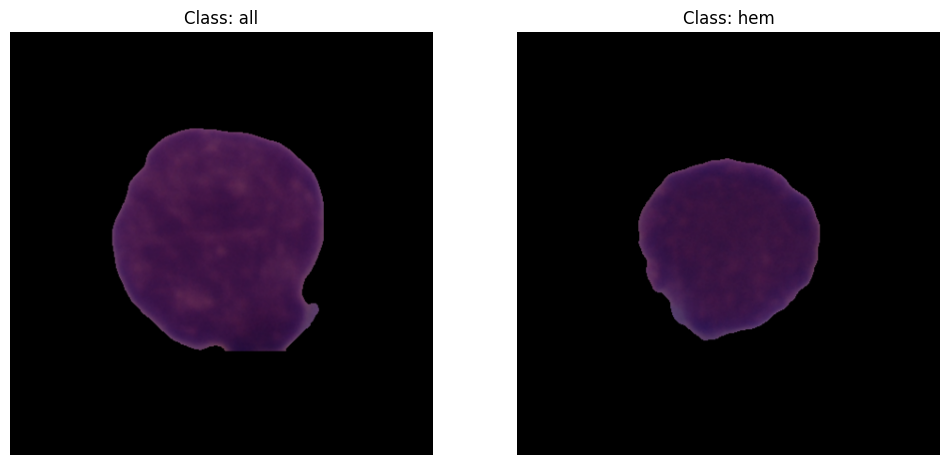

In [34]:
plt.figure(figsize=(12,6))

for i, cls in enumerate(classes):

    img_name = os.listdir(os.path.join(train_path, cls))[0]

    img_path = os.path.join(train_path, cls, img_name)

    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 2, i+1)

    plt.imshow(img)

    plt.title(f"Class: {cls}")

    plt.axis("off")

plt.show()

In [35]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 2822 images belonging to 2 classes.
Found 705 images belonging to 2 classes.


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,162,117 (95.99 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,049,604 (4.00 MB)

In [36]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

print("ResNet50 Loaded Successfully!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
ResNet50 Loaded Successfully!


In [37]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.7)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

print("Custom ResNet50 Model Created!")

Custom ResNet50 Model Created!


In [38]:
for layer in base_model.layers:
    layer.trainable = False

print("ResNet50 Layers Frozen!")

ResNet50 Layers Frozen!


In [39]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [40]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [41]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3
)

Epoch 1/3
89/89 ━━━━━━━━━━━━━━━━━━━━ 90s 833ms/step - accuracy: 0.6938 - loss: 0.6629 - val_accuracy: 0.6525 - val_loss: 0.6228
Epoch 2/3
89/89 ━━━━━━━━━━━━━━━━━━━━ 51s 577ms/step - accuracy: 0.7693 - loss: 0.5042 - val_accuracy: 0.6979 - val_loss: 0.6181
Epoch 3/3
89/89 ━━━━━━━━━━━━━━━━━━━━ 51s 574ms/step - accuracy: 0.8005 - loss: 0.4612 - val_accuracy: 0.7191 - val_loss: 0.6035


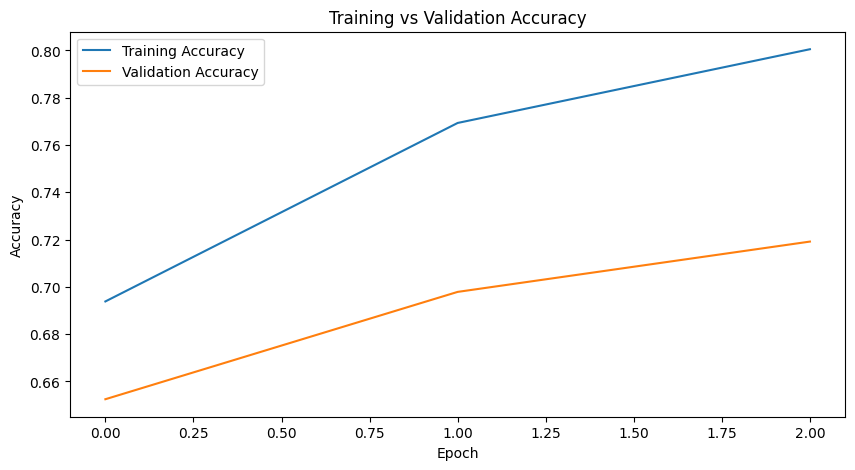

In [42]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [43]:
loss, accuracy = model.evaluate(val_generator)

print("Validation Loss:", loss)

print("Validation Accuracy:", accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 458ms/step - accuracy: 0.7064 - loss: 0.5967
Validation Loss: 0.596698522567749
Validation Accuracy: 0.7063829898834229


In [44]:
predictions = model.predict(val_generator)

predictions = (predictions > 0.5).astype(int)

true_labels = val_generator.classes

print("Predictions Generated!")

23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 610ms/step
Predictions Generated!


In [45]:
print(classification_report(true_labels, predictions))

              precision    recall  f1-score   support

           0       0.76      0.85      0.80       479
           1       0.58      0.44      0.50       226

    accuracy                           0.72       705
   macro avg       0.67      0.64      0.65       705
weighted avg       0.70      0.72      0.71       705



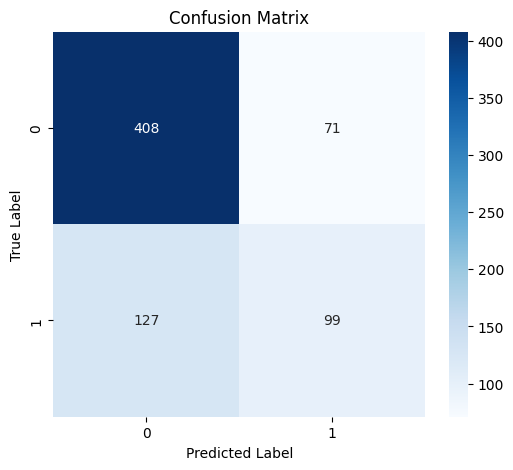

In [46]:
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

In [47]:
model.save("cell_classifier_model.keras")
print("Model saved successfully")

Model saved successfully


In [48]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [49]:
last_conv_layer_name = "conv5_block3_out"

In [50]:
def make_gradcam_heatmap(img_array, model, layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        loss = preds[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [51]:
def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img, (224,224))
    arr = np.expand_dims(img_resized, axis=0)

    arr = preprocess_input(arr)

    return img, arr

In [52]:
def show_gradcam(img, heatmap):

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Prediction: [[0.07518817]]


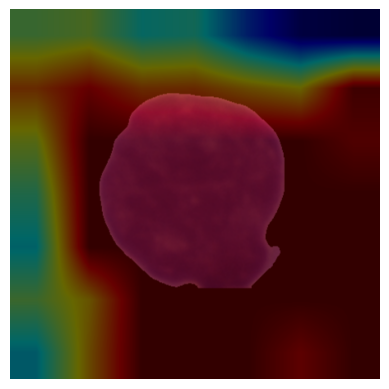

In [53]:
img_path = os.path.join(train_path, classes[0], os.listdir(os.path.join(train_path, classes[0]))[0])

img, arr = load_image(img_path)

pred = model.predict(arr)
print("Prediction:", pred)

heatmap = make_gradcam_heatmap(arr, model, last_conv_layer_name)

show_gradcam(img, heatmap)

In [54]:
def show_gradcam(img, heatmap, save_path=None):

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.imshow(overlay)
    plt.axis("off")

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)

    plt.show()

In [55]:
os.makedirs("gradcam_outputs", exist_ok=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Prediction: [[0.07518817]]


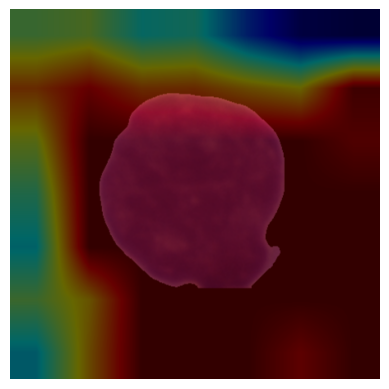

In [56]:
img_path = os.path.join(train_path, classes[0], os.listdir(os.path.join(train_path, classes[0]))[0])

img, arr = load_image(img_path)

pred = model.predict(arr)
print("Prediction:", pred)

heatmap = make_gradcam_heatmap(arr, model, last_conv_layer_name)

show_gradcam(img, heatmap, save_path="gradcam_outputs/sample_gradcam.png")

In [57]:
from google.colab import files

files.download("gradcam_outputs/sample_gradcam.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>